In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from astropy.visualization import hist
from scipy.stats import norm
import scipy
from scipy.stats import multivariate_normal

In [2]:
import sklearn

In [3]:
data = np.load("../solutions/formationchannels.npy")
np.shape(data)

(2950, 1)

Text(0.5, 0, 'Mass')

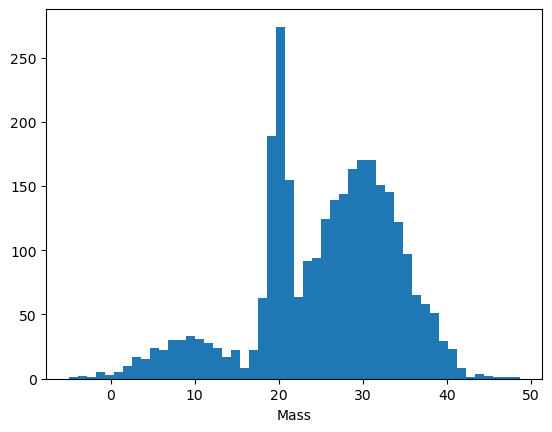

In [4]:
plt.hist(data, bins=50)
plt.xlabel('Mass')

In [5]:
gm = sklearn.mixture.GaussianMixture(n_components=3, random_state=0).fit(data)
aic = gm.aic(data)

In [6]:
print(gm.means_, '\nAIC: %.3f' % aic)

[[30.12430964]
 [20.05198472]
 [ 9.09213997]] 
AIC: 20083.309


In [7]:
means = []
weights = []
covariances =[]
aics = []
for n in range(1,11):
    gm_n = sklearn.mixture.GaussianMixture(n_components=n, random_state=0).fit(data)
    means.append(gm_n.means_)
    weights.append(gm_n.weights_)
    covariances.append(gm_n.covariances_)
    #print(gm_n.means_, gm_n.n_iter_)
    aic_n = gm_n.aic(data)
    #print(aic_n)
    aics.append(aic_n)

[0.66935985 0.21440586 0.11623429]


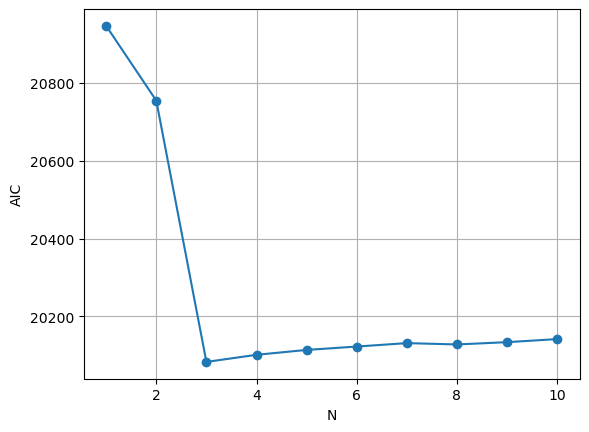

In [8]:
plt.plot(range(1,11),aics,ls='-',marker='o')
index = np.argmin(aics)
best_mean = np.reshape(means[index],len(means[index]))
best_weight = np.reshape(weights[index],len(means[index]))
best_cov = np.reshape(covariances[index],len(means[index]))
print((best_weight))
plt.xlabel('N')
plt.ylabel('AIC')
plt.grid();

In [9]:
covariances[index]

array([[[24.11386033]],

       [[ 1.13730617]],

       [[21.79683296]]])

Gaussian 1: mean: 30.124, covariance: 24.114, weight: 0.669
Gaussian 2: mean: 20.052, covariance: 1.137, weight: 0.214
Gaussian 3: mean: 9.092, covariance: 21.797, weight: 0.116


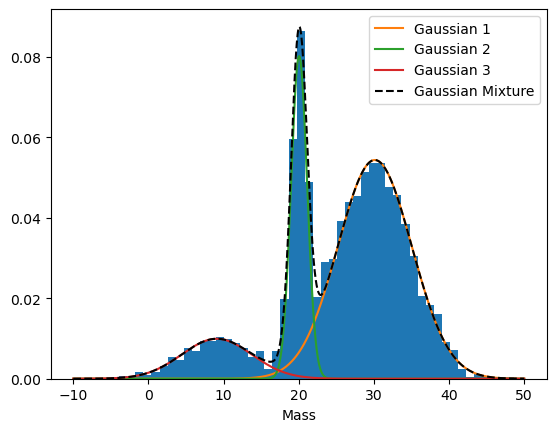

In [10]:
plt.hist(data, bins=50,density=True)
plt.xlabel('Mass')

x = np.linspace(-10,50,1000)
multi_gaus= np.zeros(1000)
for i in range(len(best_mean)):
    print('Gaussian %d: mean: %.3f, covariance: %.3f, weight: %.3f' %(i+1,best_mean[i],best_cov[i],best_weight[i]))
    gaus_i = norm(best_mean[i],np.sqrt(best_cov[i]))
    plt.plot(x,weights[index][i] * gaus_i.pdf(x),label='Gaussian '+str(i+1))
    multi_gaus += best_weight[i]*gaus_i.pdf(x)
plt.plot(x,multi_gaus, c='k', linestyle='--', label='Gaussian Mixture')
plt.legend()

In [11]:
x = np.linspace(-10,50,1000)
multi_var_distr = [multivariate_normal(mu, sigma) for (mu, sigma) in zip(best_mean, best_cov)]
components_prob = np.array([distr.pdf(x) for distr in multi_var_distr])

prob = weights[index] @ components_prob

[]

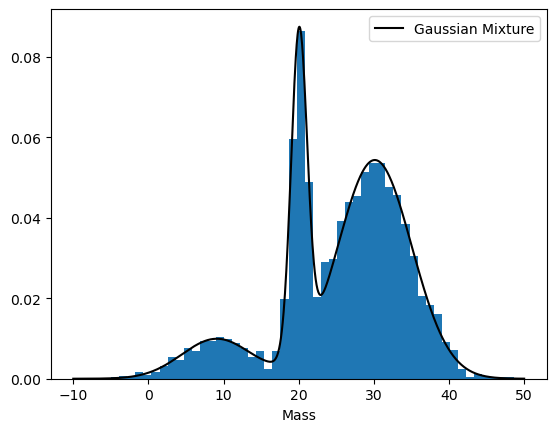

In [12]:
plt.hist(data, bins=50,density=True)
plt.xlabel('Mass')
plt.plot(x,prob,label='Gaussian Mixture', c='k')
plt.legend()
plt.plot()

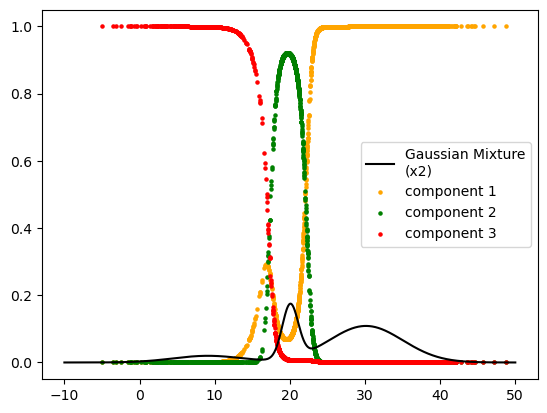

In [13]:
proba = gm.predict_proba(data)
colors = ['orange', 'g', 'r']
plt.plot(x,multi_gaus*2, c='k', linestyle='-', label='Gaussian Mixture\n(x2)')
for i, color in zip(range(3), colors): plt.scatter(data, proba[:,i],s=5,c=color,label='component '+str(i+1))

plt.legend()